In [ ]:
# Self-Organizing Maps (SOMs)

SOMs are unsupervised neural networks that reduce dimensionality and perform clustering, while preserving topological relationships.
They are useful for visualization, data compression, and exploratory analysis.


In [ ]:
| Feature       | Traditional Neural Network          | Self-Organizing Map                                      |
| ------------- | ----------------------------------- | -------------------------------------------------------- |
| Learning type | Supervised                          | Unsupervised                                             |
| Output        | Specific label or regression        | Cluster/location on a map                                |
| Goal          | Classification or prediction        | Topological mapping                                      |
| Example       | Predicting price, classifying image | Clustering similar countries, grouping similar documents |


In [ ]:
Architecture of SOM
1. Input Layer:
Each input vector has N features.
These are real-valued feature vectors (e.g., [height, weight, age, income]).

2. Output Layer:
A 2D grid of neurons (e.g., 10×10).
Each neuron has a weight vector of the same size N as the input vector.

In [ ]:
Training Process
Initialize all neuron weight vectors randomly.
For each input vector:
    Compute the Best Matching Unit (BMU): the neuron whose weight vector is closest (usually Euclidean distance) to the input.
    Update the weights of the BMU and its neighbors to become more like the input vector.
    Repeat this process over many epochs.
Over time, the neurons organize themselves so that:
      Similar input vectors activate nearby neurons.
      The map preserves topology.

In [ ]:
Step-by-Step Training

Input vector: x (shape: [N])

Neuron grid: 2D with shape [m × n]

Each neuron has weight vector: w_i (shape: [N])

Step 1: Find Best Matching Unit (BMU)
        Calculate distance from x to each w_i:

        BMU=arg min ∥𝑥−𝑤𝑖∥

Step 2: Update Weights (Only BMU and its neighbors)

        𝑤𝑖(𝑡+1)=𝑤𝑖(𝑡)+𝛼(𝑡)⋅ℎ𝑏𝑖(𝑡)⋅(𝑥−𝑤𝑖(𝑡))

Where:
α(t) is the learning rate (decays with time),
h_{bi}(t) is the neighborhood function (usually Gaussian, reduces with distance from BMU).

In [ ]:
Real-World Applications
Exploratory Data Analysis: group data before you know labels.
Text mining / WebSOM: cluster documents or news articles.
Genomics: grouping gene expression patterns.
Image compression: find representative colors or patches.
Customer segmentation: group similar shoppers.

In [ ]:
Requires setting hyperparameters: grid size, sigma, learning rate.
Can be sensitive to initialization.
Doesn’t scale well to huge datasets (but there are variants like Growing SOMs).

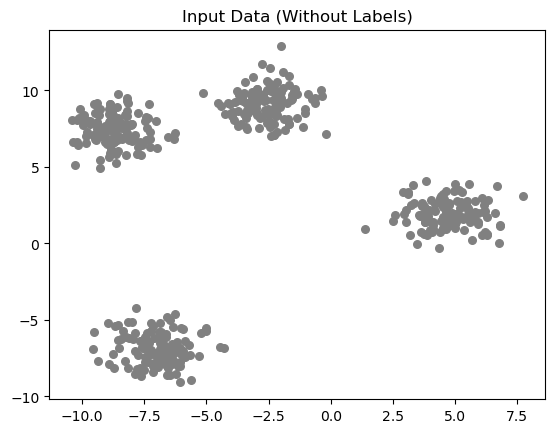

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create synthetic data (4 clusters)
X, y = make_blobs(n_samples=500, centers=4, n_features=2, random_state=42)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c='gray', s=30)
plt.title("Input Data (Without Labels)")
plt.show()


In [ ]:
class SelfOrganizingMap:
    def __init__(self, m, n, dim, lr=0.5, sigma=None, epochs=1000):
        self.m = m
        self.n = n
        self.dim = dim
        self.lr = lr
        self.sigma = sigma if sigma else max(m, n) / 2
        self.epochs = epochs
        self.weights = np.random.rand(m, n, dim)

    def _find_bmu(self, x):
        """Find best matching unit (BMU)"""
        diff = self.weights - x.reshape(1, 1, -1)
        dist = np.linalg.norm(diff, axis=2)
        return np.unravel_index(dist.argmin(), dist.shape)

    def _neighborhood(self, bmu_idx, sigma):
        """Gaussian neighborhood around BMU"""
        grid = np.indices((self.m, self.n)).transpose(1, 2, 0)
        d = np.linalg.norm(grid - bmu_idx, axis=2)
        return np.exp(-d**2 / (2 * sigma**2))

    def train(self, data):
        for epoch in range(self.epochs):
            x = data[np.random.randint(0, len(data))]  # pick a random sample
            bmu_idx = self._find_bmu(x)
            influence = self._neighborhood(bmu_idx, self.sigma)

            for i in range(self.m):
                for j in range(self.n):
                    self.weights[i, j] += self.lr * influence[i, j] * (x - self.weights[i, j])

            # Decay learning rate and sigma
            self.lr *= 0.995
            self.sigma *= 0.995


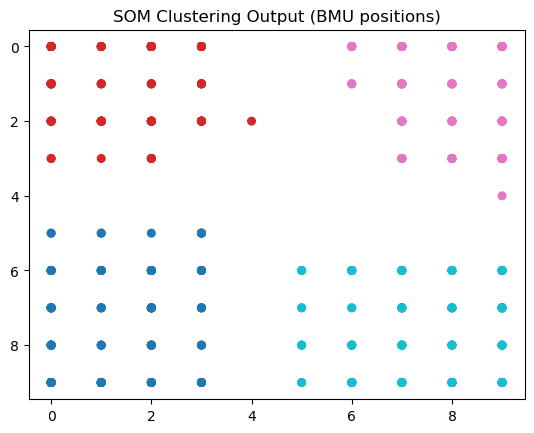

In [ ]:
som = SelfOrganizingMap(m=10, n=10, dim=2, lr=0.5, epochs=5000)
som.train(X)

# Map each point to its BMU
mapped = np.array([som._find_bmu(x) for x in X])
plt.scatter(mapped[:, 0], mapped[:, 1], c=y, cmap='tab10', s=30)
plt.title("SOM Clustering Output (BMU positions)")
plt.gca().invert_yaxis()
plt.show()


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


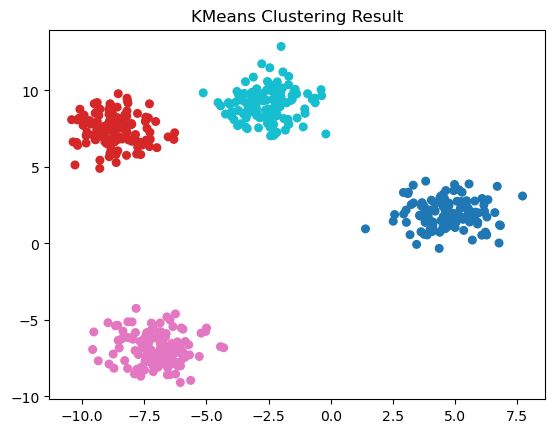

In [ ]:
# comparing with Kmeans

from sklearn.cluster import KMeans

# Fit KMeans to the data
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# Plot KMeans result
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='tab10', s=30)
plt.title("KMeans Clustering Result")
plt.show()


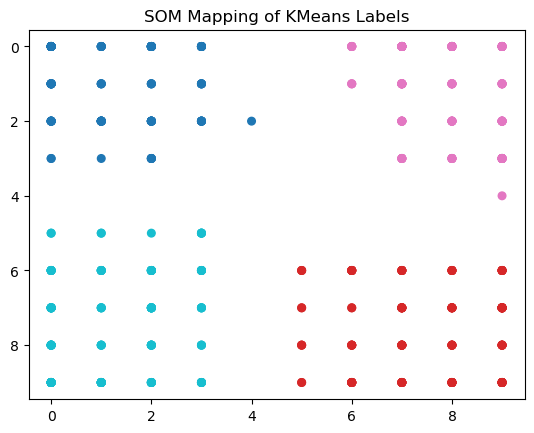

In [ ]:
# ap each input to BMU in SOM grid
mapped_bmus = np.array([som._find_bmu(x) for x in X])
plt.scatter(mapped_bmus[:, 0], mapped_bmus[:, 1], c=labels_kmeans, cmap='tab10', s=30)
plt.title("SOM Mapping of KMeans Labels")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
The KMeans plot shows cluster centers without structure.

The SOM plot shows KMeans clusters arranged on a 2D grid, revealing the topological structure learned by SOM

In [ ]:
# IRIS dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Check shape
print("Shape of data:", X_scaled.shape)


Shape of data: (150, 4)


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


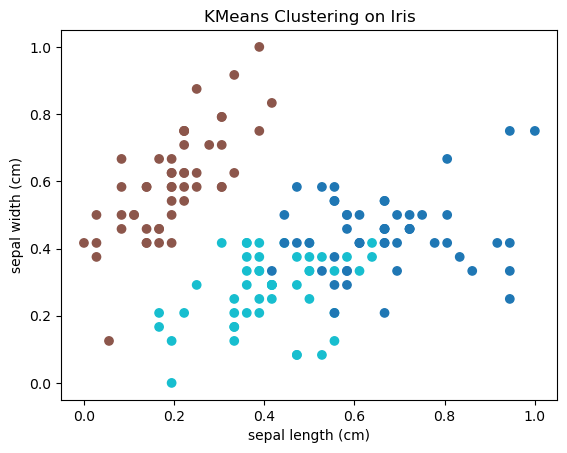

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='tab10')
plt.title("KMeans Clustering on Iris")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()


In [ ]:

som = SelfOrganizingMap(m=10, n=10, dim=4, lr=0.5, epochs=1000)
som.train(X_scaled)

# Map each point to BMU
mapped_bmus = np.array([som._find_bmu(x) for x in X_scaled])


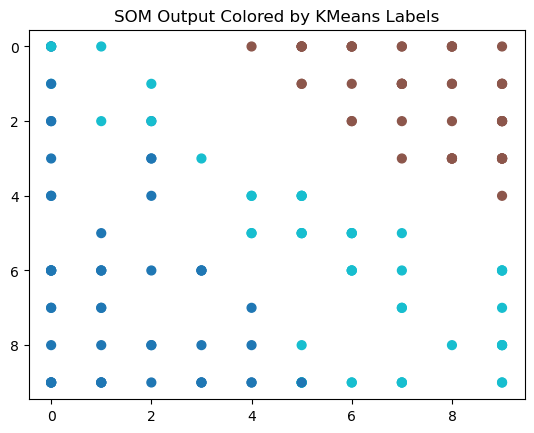

In [ ]:
plt.scatter(mapped_bmus[:, 0], mapped_bmus[:, 1], c=kmeans_labels, cmap='tab10', s=40)
plt.title("SOM Output Colored by KMeans Labels")
plt.gca().invert_yaxis()
plt.show()


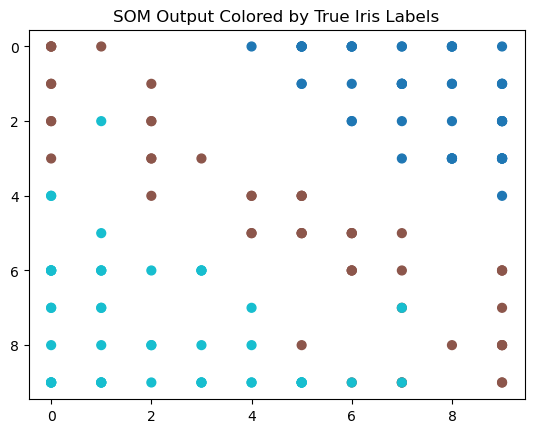

In [ ]:
plt.scatter(mapped_bmus[:, 0], mapped_bmus[:, 1], c=y, cmap='tab10', s=40)
plt.title("SOM Output Colored by True Iris Labels")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
Imagine this scenario:

You have customers described by 20 behavior features.
You want to understand them, not just group them.
KMeans

    Will tell you: “Here are 5 customer groups.”

    But won’t tell you:

        How those groups relate to each other
        Which groups are more similar
        Whether groups form subgroups

SOM

    Will give you a 2D map of the space.
    Clusters appear as regions on that map.
    Similar clusters are near each other on the grid.
    You can color-code the map by:
        Feature values
        Labels
        Clustering

In [ ]:
What is a BMU in SOM?

    Each neuron (grid cell) has a weight vector.
    For any input vector (data point), we find the neuron whose weight is closest to it — that’s the Best Matching Unit (BMU).



In [ ]:
# SOM = Grid of neurons. For each data point, find the neuron (aka node) that is closest to it.
# This closest neuron is called the Best Matching Unit (BMU).

In [ ]:
# so who decides the numebr of neurons ?
Grid Dimensions (e.g., 10×10, 15×5, etc.):

    Total number of neurons = grid width × grid height.
    More neurons → finer resolution (like more pixels on a screen).

Neuron Shape:

    Typically a 2D grid (square or rectangular).
    Can also be hexagonal or 1D in rare use cases.

# A question

# is it that only one data point be connected to a Neuron ?  


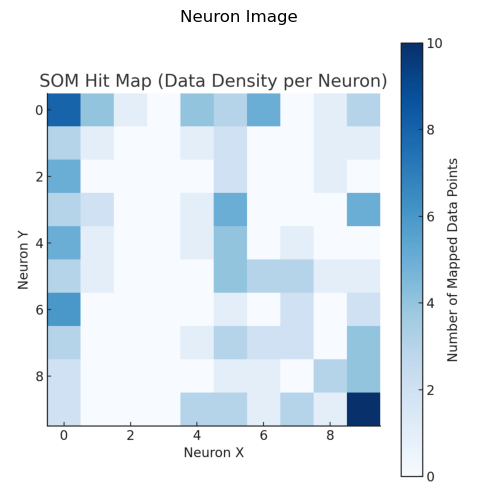

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the image with OpenCV (BGR format)
img = cv2.imread(r'C:\Users\fedex\Downloads\Neurons.png')

# Convert from BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display in Jupyter notebook
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off')  # Optional: remove axis
plt.title('Neuron Image')
plt.show()

In [ ]:
Here's the SOM Hit Map, which shows how many data points from the Iris dataset were mapped to each neuron in the 10×10 grid:
How to Read This:
    Each square is a neuron.
    The darker the square, the more data points were mapped to it.
    Blank or light squares mean no or few points landed there.
 What This Tells Us:

    Some neurons act like cluster centers—many points land there.
    Others are border zones or empty zones—they help form a structured boundary between clusters.
    It shows the density distribution of the input data on the 2D map—something KMeans cannot visualize.

In [ ]:
!pip install minisom

  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12049 sha256=568acd216ac8a2c1be3bc102f7e3ef12f17066d5fde4b2fe28505995a77b4bf6
  Stored in directory: /Users/monsley/Library/Caches/pip/wheels/76/b7/47/eb538cc16f29a1da8734d1548a0c19b642f92e46cd899eac33
Successfully built minisom


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Simulating lets say relational data, for instance customer data: [Annual Income, Spending Score]
data = np.array([
    [15, 39],
    [16, 81],
    [17, 6],
    [18, 77],
    [19, 40],
    [20, 76],
    [21, 6],
    [22, 94],
    [23, 3],
    [24, 72],
    [25, 14],
    [26, 99],
])

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)


In [ ]:
# Initialize SOM: 5x5 grid with input_len = 2 (2 features)
som = MiniSom(x=5, y=5, input_len=2, sigma=1.0, learning_rate=0.5)
som.random_weights_init(data)
som.train_random(data, num_iteration=100)


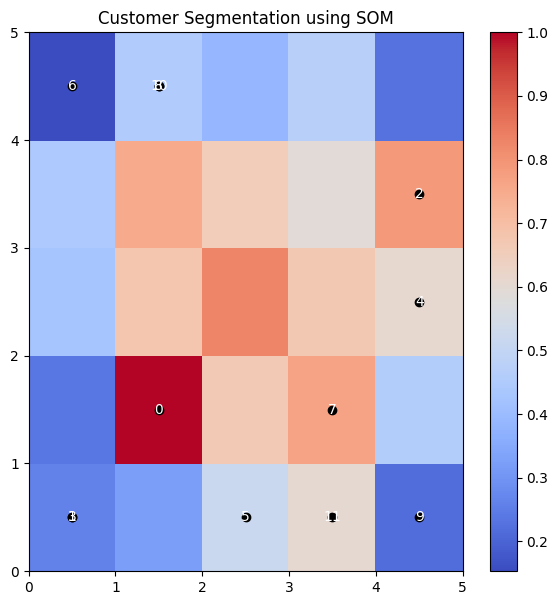

In [ ]:
# Plotting the distance map (U-Matrix)
plt.figure(figsize=(7, 7))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # U-Matrix
plt.colorbar()

# Plot the data points
for i, x in enumerate(data):
    w = som.winner(x)  # Get winning node
    plt.plot(w[0]+0.5, w[1]+0.5, 'ko')  # black circle
    plt.text(w[0]+0.5, w[1]+0.5, str(i), color='white', ha='center', va='center')

plt.title('Customer Segmentation using SOM')
plt.show()


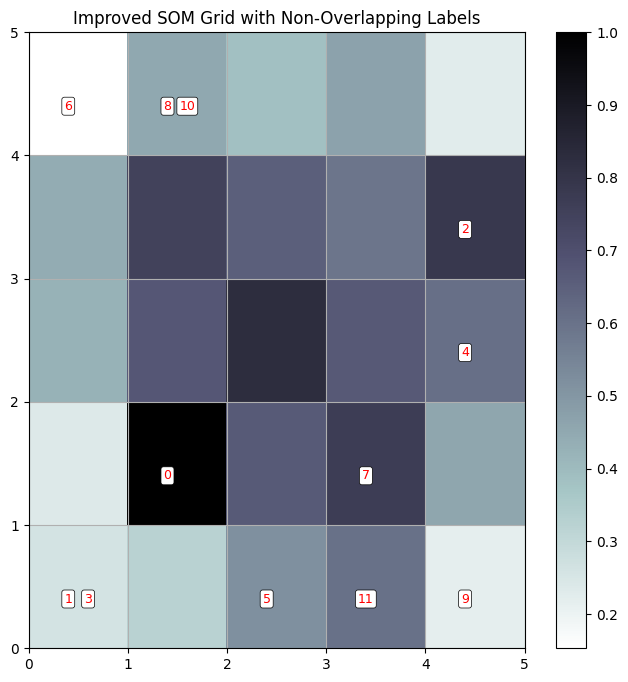

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Track which indices fall into each neuron
position_map = defaultdict(list)
for i, x in enumerate(data):
    w = som.winner(x)
    position_map[w].append(i)

# Step 2: Plot U-Matrix
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar()

# Step 3: Plot data point indices with offsets
for position, indices in position_map.items():
    x, y = position
    for j, idx in enumerate(indices):
        dx = (j % 2) * 0.2 - 0.1  # shift left/right
        dy = (j // 2) * 0.2 - 0.1  # shift up/down
        plt.text(x + 0.5 + dx, y + 0.5 + dy, str(idx),
                 color='red', ha='center', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.5))

plt.title("Improved SOM Grid with Non-Overlapping Labels")
plt.grid()
plt.show()


In [ ]:
Color in background = similarity between neurons.
Numbers = which data points got mapped where.
Same number in same neuron → same cluster.
Bright color boundaries → potential cluster edges.

In [ ]:
# Application: Intrusion detection

Use Case: Network Intrusion Detection with SOM
Dataset: NSL-KDD, a benchmark for intrusion detection systems (IDS).

Goal: Use SOM to visualize and cluster types of network attacks vs. normal activity.


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/Users/monsley/Downloads/IntrusionDataset/nsl-kdd/KDDTrain+_20Percent.txt", header=None)

# Display first few rows
print(df.head())


   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


In [ ]:
# These are standard columns followed by NSL-KDD Dataset

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]
df.columns = columns


In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from minisom import MiniSom
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/monsley/Downloads/IntrusionDataset/nsl-kdd/KDDTrain+_20Percent.txt", header=None)

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]
df.columns = columns


categorical_cols = ['protocol_type', 'service', 'flag', 'label']#Label encode categorical columns
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # Store encoders if needed later


df = df.drop(columns=['difficulty'])# Removing columns that are not relevant for present task 'difficulty'

scaler = MinMaxScaler()
X = scaler.fit_transform(df.drop(columns=['label']))# Normalize feature values
y = df['label']  # For visualization



In [ ]:
# SOM

som = MiniSom(x=10, y=10, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)
print("Training SOM...")
som.train_random(X, 1000)  # Number of iterations

Training SOM...


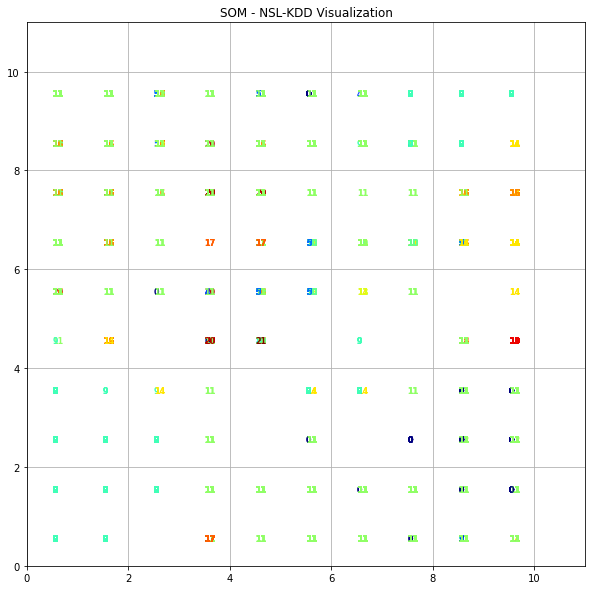

In [ ]:
x_size, y_size = 10, 10
plt.figure(figsize=(10, 10))
for i, x in enumerate(X):
    w = som.winner(x)
    plt.text(w[0] + 0.5, w[1] + 0.5, str(y.iloc[i]),
             color=plt.cm.jet(y.iloc[i] / max(y)),
             fontdict={'weight': 'bold', 'size': 8})
plt.xlim([0, x_size+1])
plt.ylim([0, y_size+1])
plt.title('SOM - NSL-KDD Visualization')
plt.grid()
plt.show()


In [ ]:
Each number represents the class/label of a data point (e.g., 0 for normal traffic, 1 for an attack).

When you see multiple numbers stacked on a cell, it means those data points were mapped to the same best matching unit (BMU) —
i.e., they are similar in feature space according to the SOM.

In [ ]:
from minisom import MiniSom

# Example training (adjust sizes as per your case)
som = MiniSom(x=15, y=15, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)
som.train_random(X, 1000)


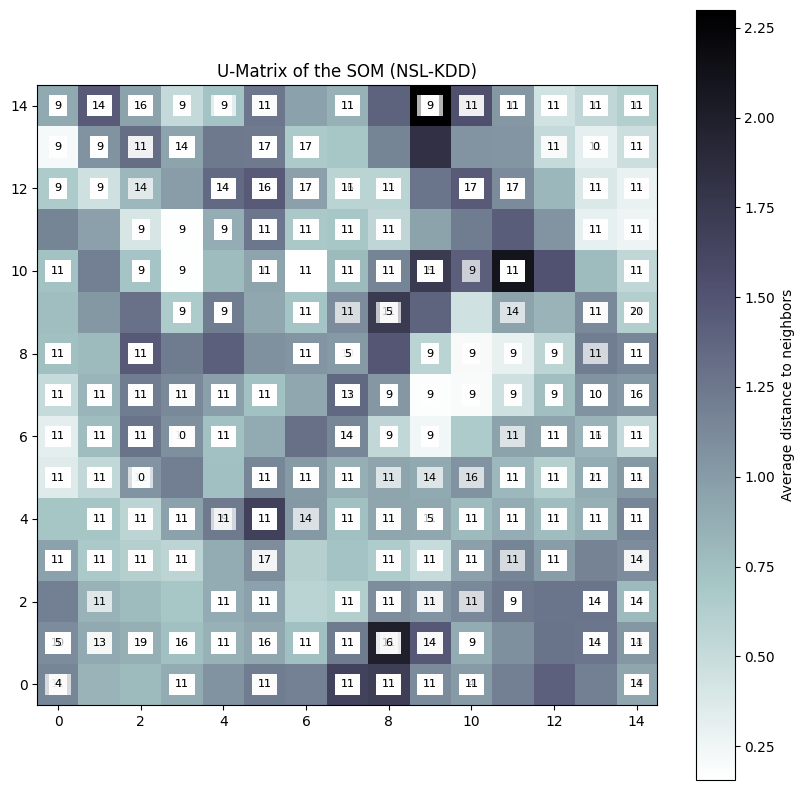

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def get_neighbors(x, y, max_x, max_y):
    neighbors = []
    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
        nx, ny = x+dx, y+dy
        if 0 <= nx < max_x and 0 <= ny < max_y:
            neighbors.append((nx, ny))
    return neighbors

def calculate_u_matrix(som):
    x_dim, y_dim = som._weights.shape[0], som._weights.shape[1]
    umatrix = np.zeros((x_dim, y_dim))
    for i in range(x_dim):
        for j in range(y_dim):
            weight = som._weights[i, j]
            neighbors = get_neighbors(i, j, x_dim, y_dim)
            distances = []
            for ni, nj in neighbors:
                neighbor_weight = som._weights[ni, nj]
                distances.append(np.linalg.norm(weight - neighbor_weight))
            umatrix[i, j] = np.mean(distances)
    return umatrix

umatrix = calculate_u_matrix(som)

plt.figure(figsize=(10, 10))
plt.imshow(umatrix.T, cmap='bone_r', origin='lower')
plt.colorbar(label='Average distance to neighbors')
plt.title('U-Matrix of the SOM (NSL-KDD)')
plt.grid(False)

# Optional: overlay class labels
for i, x in enumerate(X):
    w = som.winner(x)
    label = y.iloc[i]
    plt.text(w[0], w[1], str(label),
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7, lw=0),
             fontsize=8)

plt.show()


In [ ]:
The U-Matrix shows the average distance between the weight vector of a SOM neuron and its neighboring neurons.
helps us visualize how the data is clustered.

Dark cells / High values = Large distance to neighboring nodes → indicates a boundary or separation between clusters.

Light cells / Low values = Small distance to neighbors → indicates a dense cluster or homogeneous region.

In [ ]:
The numbers inside the grid cells represent how many data samples (input vectors) are mapped to that neuron (node).

For example, the cell labeled "17" means that 17 data points (from the dataset NSL-KDD) are best-matched to that node.

# Regions with similar color and high counts may represent attack clusters (DoS, Probe, etc.).

# Isolated or lighter regions may represent normal behavior.

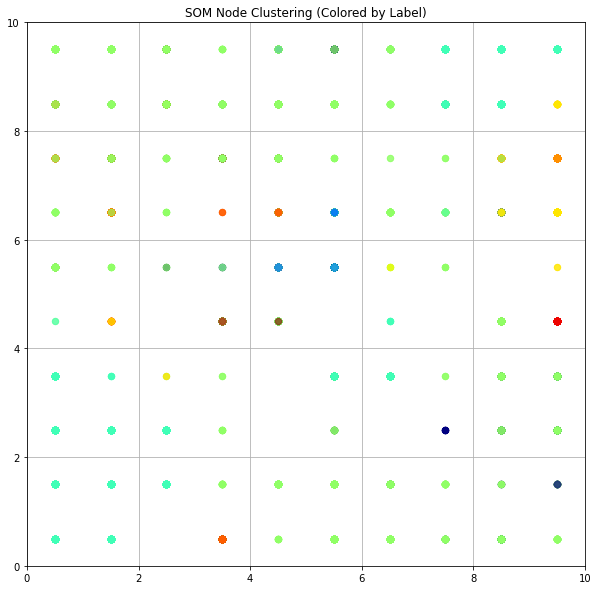

In [ ]:
# for color coded version!

from matplotlib import pyplot as plt
import numpy as np

# Visualize SOM with color-coded labels using scatter
plt.figure(figsize=(10, 10))
for i, x in enumerate(X):
    w = som.winner(x)  # Get winning neuron
    plt.scatter(w[0] + 0.5, w[1] + 0.5,
                color=plt.cm.jet(int(y.iloc[i]) / max(y)),
                alpha=0.6,  # transparency to avoid overplotting
                s=40)       # dot size

plt.xlim([0, som.get_weights().shape[0]])
plt.ylim([0, som.get_weights().shape[1]])
plt.title('SOM Node Clustering (Colored by Label)')
plt.grid()
plt.show()


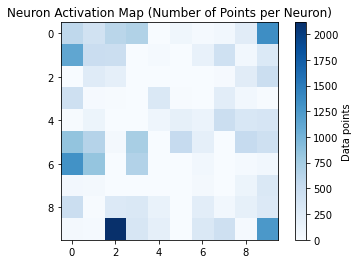

In [ ]:
#You can count how many times each neuron "wins" (i.e., is closest to any data point):

from collections import defaultdict

win_map = defaultdict(int)

for x in X:
    w = som.winner(x)
    win_map[w] += 1

# Optional: visualize usage
import matplotlib.pyplot as plt

activation_map = np.zeros((som._weights.shape[0], som._weights.shape[1]))

for (i, j), count in win_map.items():
    activation_map[i, j] = count

plt.imshow(activation_map, cmap='Blues')
plt.title("Neuron Activation Map (Number of Points per Neuron)")
plt.colorbar(label='Data points')
plt.show()
